<center><p float="center">
  <img src="https://upload.wikimedia.org/wikipedia/commons/e/e9/4_RGB_McCombs_School_Brand_Branded.png" width="300" height="100"/>
  <img src="https://mma.prnewswire.com/media/1458111/Great_Learning_Logo.jpg?p=facebook" width="200" height="100"/>
</p></center>

<center><font size=10>Neural Networks</font></center>
<center><font size=6>Model Building and Model Performance</font></center>

<center><img src="RenewableEngery.jpg" width="800" height="500"></center>

<center><font size=6>Renewable Energy</font></center>

## Problem Statement

## Business Context

Renewable energy sources play an increasingly important role in the global energy mix, as the effort to reduce the environmental impact of energy production increases.

Out of all the renewable energy alternatives, wind energy is one of the most developed technologies worldwide. The U.S Department of Energy has put together a guide to achieving operational efficiency using predictive maintenance practices.

Predictive maintenance uses sensor information and analysis methods to measure and predict degradation and future component capability. The idea behind predictive maintenance is that failure patterns are predictable and if component failure can be predicted accurately and the component is replaced before it fails, the costs of operation and maintenance will be much lower.

The sensors fitted across different machines involved in the process of energy generation collect data related to various environmental factors (temperature, humidity, wind speed, etc.) and additional features related to various parts of the wind turbine (gearbox, tower, blades, break, etc.).

## Objective

“ReneWind” is a company working on improving the machinery/processes involved in the production of wind energy using machine learning and has collected data of generator failure of wind turbines using sensors. They have shared a ciphered version of the data, as the data collected through sensors is confidential (the type of data collected varies with companies). Data has 40 predictors, 20000 observations in the training set and 5000 in the test set.

The objective is to build various classification models, tune them, and find the best one that will help identify failures so that the generators could be repaired before failing/breaking to reduce the overall maintenance cost.
The nature of predictions made by the classification model will translate as follows:

- True positives (TP) are failures correctly predicted by the model. These will result in repairing costs.
- False negatives (FN) are real failures where there is no detection by the model. These will result in replacement costs.
- False positives (FP) are detections where there is no failure. These will result in inspection costs.

It is given that the cost of repairing a generator is much less than the cost of replacing it, and the cost of inspection is less than the cost of repair.

“1” in the target variables should be considered as “failure” and “0” represents “No failure”.

## Data Description

The data provided is a transformed version of the original data which was collected using sensors.

- Train.csv - To be used for training and tuning of models.
- Test.csv - To be used only for testing the performance of the final best model.

Both the datasets consist of 40 predictor variables and 1 target variable.

The target variables should be considered as:
- “1” represents “Failure” and 
- “0” represents “No Failure”.

### Contents of Notebook (for HTML Version)
<A NAME=contents><font size=3>Table of Contents</A></font>
<OL TYPE=I>
<LI><A HREF=#eda><font size=3>Exploratory Data Analysis</font></A>
<LI><A HREF=#pd><font size=3>Problem Definition</font></A>
<LI><A HREF=#?><font size=3>Questions</font></A>
<LI><A HREF=#install><font size=3>Installing the Libraries</font></A>
<LI><A HREF=#import><font size=3>Importing Necessary Libraries</font></A>
<LI><A HREF=#ld><font size=3>Loading the Dataset</font></A>
<LI><A HREF=#do><font size=3>Data Overview</font></A>
<LI><A HREF=#bia><font size=3>Bivariate Analysis</font></A>
<LI><A HREF=#dpp><font size=3>Data Pre-Processing (Prepation for Modeling)</font></A>
<LI><A HREF=#mb><font size=3>Model Building</font></A>
<LI><A HREF=#mbod><font size=3>Model Building - Original Data</font></A>
<LI><A HREF=#mbover><font size=3>Model Building - Oversampled Data</font></A>
<LI><A HREF=#mbunder><font size=3>Model Building - Undersampled Data</font></A>
<LI><A HREF=#ht><font size=3>Hyperparameter Tuning</font></A>
<LI><A HREF=#tgbunder><font size=3>Tuning Gradient Boosting model with Undersampled Data</font></A>
<LI><A HREF=#tgbover><font size=3>Tuning Gradient Boosting model with Oversampled Data</font></A>
<LI><A HREF=#mcfms><font size=3>Model Comparison and Final Model Selection</font></A>
<LI><A HREF=#fi><font size=3>Feature Importance</font></A>
<LI><A HREF=#bir><font size=3>Business Insights and Recommendations</font></A>
<LI><A HREF=#app><font size=3>Appendix</font></A>
</OL>

### Contents of Notebook (for VS Code)
- [EDA](#exploratory-data-analysis)
- [Problem Definition](#problem-definition-and-questions-to-be-answered)
- [Questions](#questions)
- [Installing Libraries](#installing-the-libraries)
- [Importing Libraries](#importing-necessary-libraries)
- [Loading the Dataset](#loading-the-dataset)
- [Data Overview](#data-overview)
- [Bivariate Analysis](#bivariate-analysis)
- [Data Preprocessing](#data-pre-processing-prepation-for-modeling)
- [Model Building](#model-building)
  - [Model Building - Original Data](#model-building---original-data)
  - [Model Building - Oversampled Data](#model-building---oversampled-data)
  - [Model Building - Undersampled Data](#model-building---undersampled-data)
- [Hyperparameter Tuning](#hyperparameter-tuning)
  - [Tuning Gradient Boosting model with Undersampled Data](#tuning-gradient-boosting-model-with-undersampled-data)
  - [Tuning Gradient Boosting model with Oversampled Data](#tuning-gradient-boosting-model-with-oversampled-data)
- [Model Comparison and Final Model Selection](#model-comparison-and-final-model-selection)
- [Feature Importance](#feature-importance)
- [Business Insights and Recommendations](#business-insights-and-recommendations)
- [Appendix](#appendix)


## Exploratory Data Analysis (EDA) ###

<A NAME=eda><font size=3>Exploratory Data Analysis</font></A>

<A HREF=#contents><font size=3>Back to Table of Contents</font></A>

### Problem Definition and Questions to be Answered ###


<A NAME=pd><font size=3>Problem Definition</A></font>
### Problem Definition ###
ReneWind has shared confidential data of generator failure of wind turbines using sensors. The data has 40 predictors, 20000 observations in the training set and 5000 in the test set.

The objective is to build various classification models, optimize them, and find the best one that identifies failures so that the generators could be repaired before failing/breaking to reduce the overall maintenance cost.

The nature of predictions made by the classification model will translate as follows:

- True positives (TP) are failures correctly predicted by the model. These will result in repairing costs.
- False negatives (FN) are real failures where there is no detection by the model. These will result in replacement costs.
- False positives (FP) are detections where there is no failure. These will result in inspection costs.

The cost of repairing a generator is much less than the cost of replacing it, and the cost of inspection is less than the cost of repair.

### Installing the Libraries ###
<A NAME=install><font size=3>Installing the Libraries</font></A>

In [15]:
# Installing the libraries with the specified version
!pip install --no-deps tensorflow scikit-learn matplotlib seaborn numpy pandas -q --user --no-warn-script-location

**Note**:

1. After running the above cell, kindly restart the notebook kernel (for Jupyter Notebook).

2. On executing the above line of code, there may be warnings regarding package dependencies. These error messages can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in this notebook.

<A HREF=#contents><font size=3>Back to Table of Contents</font></A>

### Importing Necessary Libraries ###
<A NAME=import><font size=3>Importing Necessary Libraries</font></A>

In [49]:
# Library for data manipulation and analysis.
import pandas as pd
# Fundamental package for scientific computing.
import numpy as np
#splitting datasets into training and testing sets.
from sklearn.model_selection import train_test_split
#Imports tools for data preprocessing including label encoding, one-hot encoding, and standard scaling
from sklearn.preprocessing import LabelEncoder, OneHotEncoder,StandardScaler
#Imports a class for imputing missing values in datasets.
from sklearn.impute import SimpleImputer
#Imports the Matplotlib library for creating visualizations.
import matplotlib.pyplot as plt
# Imports the Seaborn library for statistical data visualization.
import seaborn as sns
# Time related functions.
import time
#Imports functions for evaluating the performance of machine learning models
from sklearn.metrics import confusion_matrix, f1_score,accuracy_score, recall_score, precision_score, classification_report
from sklearn.decomposition import PCA

#Imports the tensorflow,keras and layers.
import tensorflow
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dense, Input, Dropout,BatchNormalization
from tensorflow.keras import backend

# to suppress unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

In [17]:
# Set the seed using keras.utils.set_random_seed. This will set:
# 1) `numpy` seed
# 2) backend random seed
# 3) `python` random seed
tf.keras.utils.set_random_seed(812)

# If using TensorFlow, this will make GPU ops as deterministic as possible,
# but it will affect the overall performance, so be mindful of that.
tf.config.experimental.enable_op_determinism()

### Loading the Dataset ###
<A NAME=ld><font size=3>Loading the Dataset</font></A>

In [18]:
# Loading the dataset
Test = pd.read_csv('Test.csv')
Data = pd.read_csv('Train.csv')

### Data Overview ###
<A NAME=do><font size=3>Data Overview</font></A>

<A HREF=#contents><font size=3>Back to Table of Contents</font></A>

* Observations
* Sanity Checks
* Missing Values Treatement

In [19]:
# Displaying the first five rows of the Test dataset
Data.head().T

,0,1,2,3,4
V1,-4.464606,3.365912,-3.831843,1.618098,-0.111440
V2,-4.679129,3.653381,-5.824444,1.888342,3.872488
V3,3.101546,0.909671,0.634031,7.046143,-3.758361
V4,0.506130,-1.367528,-2.418815,-1.147285,-2.982897
V5,-0.221083,0.332016,-1.773827,0.083080,3.792714
V6,-2.032511,2.358938,1.016824,-1.529780,0.544960
V7,-2.910870,0.732600,-2.098941,0.207309,0.205433
V8,0.050714,-4.332135,-3.173204,-2.493629,4.848994
V9,-1.522351,0.565695,-2.081860,0.344926,-1.854920
V10,3.761892,-0.101080,5.392621,2.118578,-6.220023


In [20]:
# Displaying the last five rows of the Test dataset
Data.tail().T

,19995,19996,19997,19998,19999
V1,-2.071318,2.890264,-3.896979,-3.187322,-2.686903
V2,-1.088279,2.483069,-3.942407,-10.051662,1.961187
V3,-0.796174,5.643919,-0.351364,5.695955,6.137088
V4,-3.011720,0.937053,-2.417462,-4.370053,2.600133
V5,-2.287540,-1.380870,1.107546,-5.354758,2.657241
V6,2.807310,0.412051,-1.527623,-1.873044,-4.290882
V7,0.481428,-1.593386,-3.519882,-3.947210,-2.344267
V8,0.105171,-5.762498,2.054792,0.679420,0.974004
V9,-0.586599,2.150096,-0.233996,-2.389254,-1.027462
V10,-2.899398,0.272302,-0.357687,5.456756,0.497421


In [21]:
# Checking shape of the Test and Train
print(f"There are {Data.shape[0]} rows and {Data.shape[1]}.")


There are 20000 rows and 41.


In [22]:
# Views a sample of the Test data
Data.sample(n=10, random_state=42).T

,10650,2041,8668,1114,13902,11963,11072,3002,19771,8115
V1,-1.614376,1.568145,2.589417,5.949625,-3.739613,-0.682858,-4.309469,3.367090,-0.917169,2.740802
V2,-1.736670,-1.027898,1.223931,0.069607,-5.690478,2.339220,-4.741085,-3.822749,3.544770,1.920928
V3,-2.813407,2.248354,-1.333839,5.654639,4.928991,1.715817,-2.605958,-0.493089,2.466400,6.849078
V4,2.221800,4.621097,1.387510,-2.747775,-4.232019,1.401154,4.851168,-4.817188,2.323309,-1.507336
V5,0.037058,-2.446727,0.515199,-2.595593,-0.752365,2.339567,1.631844,-2.058935,-0.357099,-0.623465
V6,-0.548029,-4.594830,-1.380089,-0.528190,-1.125413,-3.098022,-1.176013,-0.167743,-1.927897,-0.363897
V7,-1.996175,-1.530458,0.029258,-0.938213,-2.476994,1.979678,-3.777214,-0.437299,2.965424,-0.305328
V8,1.669646,3.826295,1.652332,-2.509881,1.548190,5.421472,3.266404,3.678254,1.451094,-4.472270
V9,-0.003629,3.017331,1.171832,0.956434,-4.259632,-5.640014,-3.179105,-2.166721,-1.879011,1.930132
V10,-0.311030,-2.668953,-1.114216,0.833862,4.087510,0.940457,3.907624,0.305837,-1.176436,1.222949


In [23]:
#Tells us data types and if we have missing data in the Test dataset
Data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 41 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   V1      19982 non-null  float64
 1   V2      19982 non-null  float64
 2   V3      20000 non-null  float64
 3   V4      20000 non-null  float64
 4   V5      20000 non-null  float64
 5   V6      20000 non-null  float64
 6   V7      20000 non-null  float64
 7   V8      20000 non-null  float64
 8   V9      20000 non-null  float64
 9   V10     20000 non-null  float64
 10  V11     20000 non-null  float64
 11  V12     20000 non-null  float64
 12  V13     20000 non-null  float64
 13  V14     20000 non-null  float64
 14  V15     20000 non-null  float64
 15  V16     20000 non-null  float64
 16  V17     20000 non-null  float64
 17  V18     20000 non-null  float64
 18  V19     20000 non-null  float64
 19  V20     20000 non-null  float64
 20  V21     20000 non-null  float64
 21  V22     20000 non-null  float64
 22

* Out of 40 columns V1 has 5 and V2 6 missing records.
* Columns V40 has a data type of int64.

<A HREF=#contents><font size=3>Back to Table of Contents</font></A>

* Out of 40 columns V1 and V2 has 18 missing records.
* Columns V40 has a data type of int64.

<A HREF=#contents><font size=3>Back to Table of Contents</font></A>

In [24]:
# Provides details on the Test data
Data.describe(include='all').T

,count,mean,std,min,25%,50%,75%,max
V1,19982.0,-0.271996,3.441625,-11.876451,-2.737146,-0.747917,1.840112,15.493002
V2,19982.0,0.440430,3.150784,-12.319951,-1.640674,0.471536,2.543967,13.089269
V3,20000.0,2.484699,3.388963,-10.708139,0.206860,2.255786,4.566165,17.090919
V4,20000.0,-0.083152,3.431595,-15.082052,-2.347660,-0.135241,2.130615,13.236381
V5,20000.0,-0.053752,2.104801,-8.603361,-1.535607,-0.101952,1.340480,8.133797
V6,20000.0,-0.995443,2.040970,-10.227147,-2.347238,-1.000515,0.380330,6.975847
V7,20000.0,-0.879325,1.761626,-7.949681,-2.030926,-0.917179,0.223695,8.006091
V8,20000.0,-0.548195,3.295756,-15.657561,-2.642665,-0.389085,1.722965,11.679495
V9,20000.0,-0.016808,2.160568,-8.596313,-1.494973,-0.067597,1.409203,8.137580
V10,20000.0,-0.012998,2.193201,-9.853957,-1.411212,0.100973,1.477045,8.108472


In [25]:
# Checking for duplicate values in the data
Data.duplicated().sum()

np.int64(0)

In [26]:
# Checking for missing values in the data
round(Data.isnull().sum() / Data.isnull().count() * 100, 2)

V1        0.09
V2        0.09
V3        0.00
V4        0.00
V5        0.00
V6        0.00
V7        0.00
V8        0.00
V9        0.00
V10       0.00
V11       0.00
V12       0.00
V13       0.00
V14       0.00
V15       0.00
V16       0.00
V17       0.00
V18       0.00
V19       0.00
V20       0.00
V21       0.00
V22       0.00
V23       0.00
V24       0.00
V25       0.00
V26       0.00
V27       0.00
V28       0.00
V29       0.00
V30       0.00
V31       0.00
V32       0.00
V33       0.00
V34       0.00
V35       0.00
V36       0.00
V37       0.00
V38       0.00
V39       0.00
V40       0.00
Target    0.00
dtype: float64

In [58]:
## Separating Independent and Dependent Columns
X = Data.drop(['Target'],axis=1)
Y = Data['Target']

In [59]:
#Calculating the total number of nan values for each columns.
X.isnull().sum()

V1     18
V2     18
V3      0
V4      0
V5      0
V6      0
V7      0
V8      0
V9      0
V10     0
V11     0
V12     0
V13     0
V14     0
V15     0
V16     0
V17     0
V18     0
V19     0
V20     0
V21     0
V22     0
V23     0
V24     0
V25     0
V26     0
V27     0
V28     0
V29     0
V30     0
V31     0
V32     0
V33     0
V34     0
V35     0
V36     0
V37     0
V38     0
V39     0
V40     0
dtype: int64

In [60]:
X.columns

Index(['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11',
       'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21',
       'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'V29', 'V30', 'V31',
       'V32', 'V33', 'V34', 'V35', 'V36', 'V37', 'V38', 'V39', 'V40'],
      dtype='object')

In [61]:
#Calculating the total number of nan values for each columns.
X.isnull().sum()

V1     18
V2     18
V3      0
V4      0
V5      0
V6      0
V7      0
V8      0
V9      0
V10     0
V11     0
V12     0
V13     0
V14     0
V15     0
V16     0
V17     0
V18     0
V19     0
V20     0
V21     0
V22     0
V23     0
V24     0
V25     0
V26     0
V27     0
V28     0
V29     0
V30     0
V31     0
V32     0
V33     0
V34     0
V35     0
V36     0
V37     0
V38     0
V39     0
V40     0
dtype: int64

In [62]:
imputer_mode = SimpleImputer(strategy="most_frequent")
X[["V1","V2"]] = imputer_mode.fit_transform(
    X[["V1","V2"]])

In [63]:
#Calculating the total number of nan values for each columns.
X.isnull().sum()

V1     0
V2     0
V3     0
V4     0
V5     0
V6     0
V7     0
V8     0
V9     0
V10    0
V11    0
V12    0
V13    0
V14    0
V15    0
V16    0
V17    0
V18    0
V19    0
V20    0
V21    0
V22    0
V23    0
V24    0
V25    0
V26    0
V27    0
V28    0
V29    0
V30    0
V31    0
V32    0
V33    0
V34    0
V35    0
V36    0
V37    0
V38    0
V39    0
V40    0
dtype: int64

In [27]:
Data["Target"].value_counts(1)*100

Target
0    94.45
1     5.55
Name: proportion, dtype: float64

- There are only 5.5% Failures and 94.45% that are No Failure.


<A HREF=#contents><font size=3>Back to Table of Contents</font></A>

## Exploratory Data Analysis ##

<A NAME=eda><font size=3>Exploratory Data Analysis</font></A>

- EDA is an important part of any project involving data.
- This section contains Univariate Analysis and Bivariate Analysis to investigate and understand the data better before building a model with it.
- Return to [Questions:](#Questions:) above, and/or the below to see key meaningful observations for all data, plots, and graphs. 

The below functions need to be defined to carry out the EDA.


In [28]:
# function to create labeled barplots
def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 2, 6))
    else:
        plt.figure(figsize=(n + 2, 6))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n],
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

In [29]:
# Function to plot a boxplot and a histogram along the same scale.

def histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12,7))
    kde: whether to the show density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a star will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, palette="winter"
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

In [30]:
### Function to plot distributions
def distribution_plot_wrt_target(data, predictor, target):

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    target_uniq = data[target].unique()

    axs[0, 0].set_title("Distribution of target for target=" + str(target_uniq[0]))
    sns.histplot(
        data=data[data[target] == target_uniq[0]],
        x=predictor,
        kde=True,
        ax=axs[0, 0],
        color="teal",
    )

    axs[0, 1].set_title("Distribution of target for target=" + str(target_uniq[1]))
    sns.histplot(
        data=data[data[target] == target_uniq[1]],
        x=predictor,
        kde=True,
        ax=axs[0, 1],
        color="orange",
    )

    axs[1, 0].set_title("Boxplot w.r.t target")
    sns.boxplot(data=data, x=target, y=predictor, ax=axs[1, 0], palette="gist_rainbow")

    axs[1, 1].set_title("Boxplot (without outliers) w.r.t target")
    sns.boxplot(
        data=data,
        x=target,
        y=predictor,
        ax=axs[1, 1],
        showfliers=False,
        palette="gist_rainbow",
    )

    plt.tight_layout()
    plt.show()

In [31]:
# function to plot stacked bar chart
def stacked_barplot(data, predictor, target):
    """
    Print the category counts and plot a stacked bar chart

    data: dataframe
    predictor: independent variable
    target: target variable
    """
    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    print(tab1)
    print("-" * 120)
    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(
        by=sorter, ascending=False
    )
    tab.plot(kind="bar", stacked=True, figsize=(count + 1, 5))
    plt.legend(
        loc="lower left",
        frameon=False,
    )
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()

<A HREF=#contents><font size=3>Back to Table of Contents</font></A>

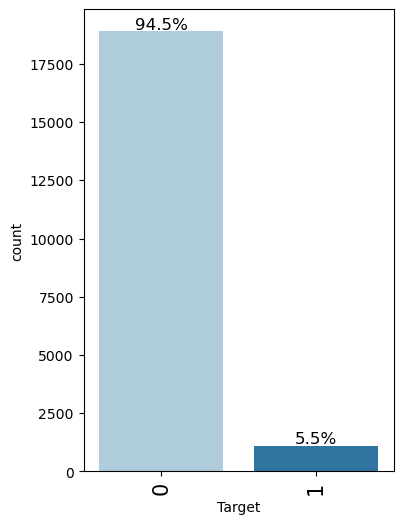

In [32]:
labeled_barplot(Data,"Target",perc=True)

Return to [Questions:](#Questions:) 

<A HREF=#?><font size=3>Return to Questions</font></A>

### Utility functions

In [65]:
def plot(history, name):
    """
    Function to plot loss/accuracy

    history: an object which stores the metrics and losses.
    name: can be one of Loss or Accuracy
    """
    fig, ax = plt.subplots() #Creating a subplot with figure and axes.
    plt.plot(history.history[name]) #Plotting the train accuracy or train loss
    plt.plot(history.history['val_'+name]) #Plotting the validation accuracy or validation loss

    plt.title('Model ' + name.capitalize()) #Defining the title of the plot.
    plt.ylabel(name.capitalize()) #Capitalizing the first letter.
    plt.xlabel('Epoch') #Defining the label for the x-axis.
    fig.legend(['Train', 'Validation'], loc="outside right upper") #Defining the legend, loc controls the position of the legend.

In [66]:
# defining a function to compute different metrics to check performance of a classification model built using statsmodels
def model_performance_classification(
    model, predictors, target, threshold=0.5
):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    threshold: threshold for classifying the observation as class 1
    """

    # checking which probabilities are greater than threshold
    pred = model.predict(predictors) > threshold
    # pred_temp = model.predict(predictors) > threshold
    # # rounding off the above values to get classes
    # pred = np.round(pred_temp)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred, average='weighted')  # to compute Recall
    precision = precision_score(target, pred, average='weighted')  # to compute Precision
    f1 = f1_score(target, pred, average='weighted')  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1 Score": f1,},
        index=[0],
    )

    return df_perf

## Model Building

<A NAME=mb><font size=3>Model Building</font></A>

<A HREF=#contents><font size=3>Back to Table of Contents</font></A>

### Model evaluation criterion

**The Models below can wrongly:**
* FP - Predict that a visa applicant will get certified but in reality, the visa application gets denied.
* FN - Predict that a visa applicant will not get certified but in reality, the visa application gets certified.

**Which case is more important?**
* Both the cases are important as:

* If a visa is certified when it should be denied, the wrong employee will get the job position and a US citizen will not receive an opportunity for a position.

* If a visa is denied when it should be certified, the US job market loses a suitable employee that could have contributed to the economy.

**How to reduce the losses?**

* `F1 Score` can be used a the metric for evaluation of the model, greater the `F1 Score` higher are the chances of minimizing False Negatives and False Positives.
* We will use balanced class weights so that model focuses equally on both classes.
* `model_performance_classification_sklearn` function will be used to check the model performance of models.
* `confusion_matrix_sklearn` function will be used to plot the confusion matrix.

### Splitting the dataset

In [67]:
# Splitting the dataset into the Training and Test set.
X_train, X_test, y_train, y_test = train_test_split(X,Y, test_size = 0.2, random_state = 42,stratify = Y)

In [68]:
# Splitting the Train dataset into the Training and Validation set.
X_train, X_valid, y_train, y_valid = train_test_split(X_train,y_train, test_size = 0.2, random_state = 42,stratify = y_train)

In [69]:
#Printing the shapes.
print(X_train.shape,y_train.shape)
print(X_valid.shape,y_valid.shape)
print(X_test.shape,y_test.shape)

(12800, 40) (12800,)
(3200, 40) (3200,)
(4000, 40) (4000,)


In [70]:
y_train = y_train.to_numpy()
y_valid = y_valid.to_numpy()
y_test = y_test.to_numpy()

### Utility functions

In [72]:
def plot(history, name):
    """
    Function to plot loss/accuracy

    history: an object which stores the metrics and losses.
    name: can be one of Loss or Accuracy
    """
    fig, ax = plt.subplots() #Creating a subplot with figure and axes.
    plt.plot(history.history[name]) #Plotting the train accuracy or train loss
    plt.plot(history.history['val_'+name]) #Plotting the validation accuracy or validation loss

    plt.title('Model ' + name.capitalize()) #Defining the title of the plot.
    plt.ylabel(name.capitalize()) #Capitalizing the first letter.
    plt.xlabel('Epoch') #Defining the label for the x-axis.
    fig.legend(['Train', 'Validation'], loc="outside right upper") #Defining the legend, loc controls the position of the legend.

In [73]:
# defining a function to compute different metrics to check performance of a classification model built using statsmodels
def model_performance_classification(
    model, predictors, target, threshold=0.5
):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    threshold: threshold for classifying the observation as class 1
    """

    # checking which probabilities are greater than threshold
    pred = model.predict(predictors) > threshold
    # pred_temp = model.predict(predictors) > threshold
    # # rounding off the above values to get classes
    # pred = np.round(pred_temp)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred, average='weighted')  # to compute Recall
    precision = precision_score(target, pred, average='weighted')  # to compute Precision
    f1 = f1_score(target, pred, average='weighted')  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1 Score": f1,},
        index=[0],
    )

    return df_perf

## Model Building

### Model Evaluation Criteria

**A model can make wrong predictions in the following ways:**
* Predicting an employee is looking for a job, when he/she is not looking for it.
* Predicting an employee is not looking for a job, when he/she is in fact looking for one.

**Which case is more important?**

Both cases are actually important for the purposes of this case study. Not giving a chance to a deserving employee (by wrongly classifying them as likely to attrite) might lead to decreased productivity, and the company might lose a good employee affecting the organization's growth. However, giving chances to a non-deserving employee (as they are likely to attrite) would lead to a financial loss for the company, and giving such employees an increased amount of responsibility might again affect the company's growth.

**How to reduce this loss i.e need to reduce False Negatives as well as False Positives?**

Since both errors are important for us to minimize, the company would want the F1 Score evaluation metric to be maximized/ Hence, the focus should be on increasing the F1 score rather than focusing on just one metric i.e. Recall or Precision.


In [74]:
# Calculate class weights for imbalanced dataset
cw = (y_train.shape[0]) / np.bincount(y_train)

# Create a dictionary mapping class indices to their respective class weights
cw_dict = {}
for i in range(cw.shape[0]):
    cw_dict[i] = cw[i]

cw_dict

{0: np.float64(1.0587262200165426), 1: np.float64(18.028169014084508)}

In [116]:
# defining the batch size and # epochs upfront as we'll be using the same values for all models
epochs = 30
batch_size = 128

#### Model Building - Original Data

<A NAME=mbod><font size=3>Model Building - Original Data</font></A>

- Let's start with a neural network consisting of
  - two hidden layers with 14 and 7 neurons respectively
  - activation function of ReLU.
  - SGD as the optimizer

In [117]:
# clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

In [122]:
#Initializing the neural network
model = Sequential()
model.add(Dense(14,activation="relu",input_dim=X_train.shape[1]))
model.add(Dense(7,activation="relu"))
model.add(Dense(1,activation="sigmoid"))

In [123]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 14)             │           574 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 7)              │           105 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             8 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 687 (2.68 KB)

 Trainable params: 687 (2.68 KB)

 Non-trainable params: 0 (0.00 B)

In [124]:
optimizer = tf.keras.optimizers.SGD()    # defining SGD as the optimizer to be used
model.compile(loss='binary_crossentropy', optimizer=optimizer)

In [125]:
start = time.time()
history = model.fit(X_train, y_train, validation_data=(X_valid,y_valid), batch_size=batch_size, epochs=epochs,class_weight=cw_dict)
end=time.time()

Epoch 1/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.1415 - val_loss: 0.4810
Epoch 2/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.8338 - val_loss: 0.3733
Epoch 3/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7133 - val_loss: 0.3142
Epoch 4/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6385 - val_loss: 0.2802
Epoch 5/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5928 - val_loss: 0.2603
Epoch 6/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5663 - val_loss: 0.2459
Epoch 7/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5454 - val_loss: 0.2336
Epoch 8/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5253 - val_loss: 0.2193
Epoch 9/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5015 - val_loss: 0.2068
Epoch 10/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4787 - val_loss: 0.1938
Epoch 11/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4573 - val_loss: 0.1816
Epoch 12/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

In [126]:
print("Time taken in seconds ",end-start)

Time taken in seconds  10.73860239982605


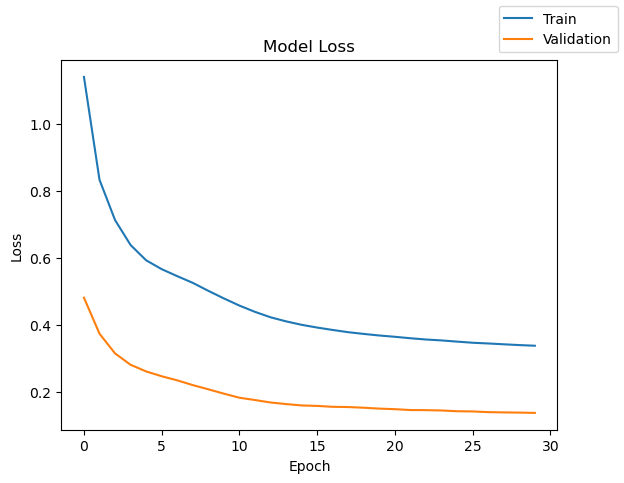

In [127]:
plot(history,'loss')

In [128]:
model_0_train_perf = model_performance_classification(model, X_train, y_train)
model_0_train_perf

400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.973203,0.973203,0.978622,0.974949


In [129]:
model_0_valid_perf = model_performance_classification(model, X_valid, y_valid)
model_0_valid_perf

100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.972187,0.972187,0.976523,0.9737


- Train F1 score of ~0.974 and Valid F1 score of ~0.973 indicate consistent performance of the model between the train and Valid datasets.

- Even though it's a good score, the rate of improvement over the epochs is still low.

#### Model 1

- After the 5th epoch, the model's rate of learning is low.
- Let's try adding momentum to check whether it's accelerating the learning process.

In [130]:
# clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

In [131]:
#Initializing the neural network
model = Sequential()
model.add(Dense(14,activation="relu",input_dim=X_train.shape[1]))
model.add(Dense(7,activation="relu"))
model.add(Dense(1,activation="sigmoid"))

In [132]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 14)             │           574 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           105 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             8 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 687 (2.68 KB)

 Trainable params: 687 (2.68 KB)

 Non-trainable params: 0 (0.00 B)

In [134]:
optimizer = tf.keras.optimizers.SGD(momentum=0.9)    # defining SGD as the optimizer to be used
model.compile(loss='binary_crossentropy', optimizer=optimizer)

In [135]:
start = time.time()
history = model.fit(X_train, y_train, validation_data=(X_valid,y_valid) , batch_size=batch_size, epochs=epochs,class_weight = cw_dict)
end=time.time()

Epoch 1/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.7783 - val_loss: 0.2038
Epoch 2/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5056 - val_loss: 0.1815
Epoch 3/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4559 - val_loss: 0.1393
Epoch 4/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4365 - val_loss: 0.1313
Epoch 5/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4163 - val_loss: 0.1178
Epoch 6/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3916 - val_loss: 0.1141
Epoch 7/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3784 - val_loss: 0.1043
Epoch 8/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3598 - val_loss: 0.1014
Epoch 9/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3535 - val_loss: 0.0996
Epoch 10/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3384 - val_loss: 0.0853
Epoch 11/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3360 - val_loss: 0.0968
Epoch 12/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

In [136]:
print("Time taken in seconds ",end-start)

Time taken in seconds  11.501970767974854


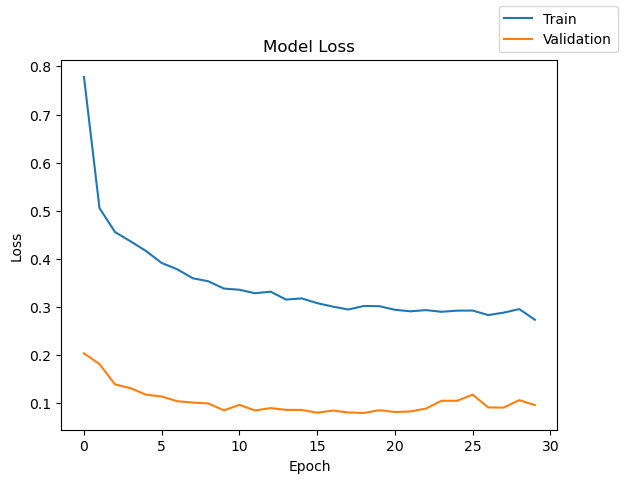

In [137]:
plot(history,'loss')

In [138]:
model_1_train_perf = model_performance_classification(model, X_train, y_train)
model_1_train_perf

400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.991719,0.991719,0.99173,0.991724


In [139]:
model_1_valid_perf = model_performance_classification(model, X_valid, y_valid)
model_1_valid_perf

100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.983437,0.983437,0.983312,0.983371


#### Model Building - Oversampled Data

<A NAME=mbover><font size=3>Model Building - Oversampled Data</font></A>

<A HREF=#contents><font size=3>Back to Table of Contents</font></A>

In [ ]:
print("Before Oversampling, counts of label 'Certified': {}".format(sum(y_train == 1)))
print("Before Oversampling, counts of label 'Denied': {} \n".format(sum(y_train == 0)))

sm = SMOTE(
    sampling_strategy=1, k_neighbors=5, random_state=1
)  # Synthetic Minority Over Sampling Technique
X_train_over, y_train_over = sm.fit_resample(X_train, y_train)


print("After Oversampling, counts of label 'Certified': {}".format(sum(y_train_over == 1)))
print("After Oversampling, counts of label 'Denied': {} \n".format(sum(y_train_over == 0)))


print("After Oversampling, the shape of train_X: {}".format(X_train_over.shape))
print("After Oversampling, the shape of train_y: {} \n".format(y_train_over.shape))

In [ ]:
models = []  # Empty list to store all the models

# Appending models into the list
models.append(("Bagging", BaggingClassifier(estimator=DecisionTreeClassifier(random_state=1, class_weight='balanced'), random_state=1)))
models.append(("Random forest", RandomForestClassifier(random_state=1, class_weight='balanced')))
models.append(("GBM", GradientBoostingClassifier(random_state=1)))
models.append(("Adaboost", AdaBoostClassifier(random_state=1)))
models.append(("dtree", DecisionTreeClassifier(random_state=1, class_weight='balanced')))

print("\n" "Training Performance:" "\n")
for name, model in models:
    model.fit(X_train_over, y_train_over)
    scores = recall_score(y_train_over, model.predict(X_train_over))
    print("{}: {}".format(name, scores))

print("\n" "Validation Performance:" "\n")

for name, model in models:
    model.fit(X_train_over, y_train_over)
    scores = recall_score(y_val, model.predict(X_val))
    print("{}: {}".format(name, scores))

In [ ]:
print("\nOversampling - Training and Validation Performance Difference:\n")

for name, model in models:
    model.fit(X_train_over, y_train_over)
    scores_train = recall_score(y_train_over, model.predict(X_train_over))
    scores_val = recall_score(y_val, model.predict(X_val))
    difference2 = scores_train - scores_val
    print("{}: Training Score: {:.4f}, Validation Score: {:.4f}, Difference: {:.4f}".format(name, scores_train, scores_val, difference2))

- GBM has the best performance followed by Adaboost model as per the validation performance

#### Model Building - Undersampled Data

<A NAME=mbunder><font size=3>Model Building - Undersampled Data</font></A>

<A HREF=#contents><font size=3>Back to Table of Contents</font></A>

There is a difference between the Training data and the Validation data. The difference between the Train and Validation data are:
* Train:
  - There is 14% False Negatives and 19% False Positives. 
* Validation:
  - There is  9% False Negatives and 25% False Positives. 

In [ ]:
rus = RandomUnderSampler(random_state=1)
X_train_un, y_train_un = rus.fit_resample(X_train, y_train)

In [ ]:
print("Before Undersampling, counts of label 'Certified': {}".format(sum(y_train == 1)))
print("Before Undersampling, counts of label 'Denied' {} \n".format(sum(y_train == 0)))

print("After Undersampling, counts of label 'Certified': {}".format(sum(y_train_un == 1)))
print("After Undersampling, counts of label 'Denied': {} \n".format(sum(y_train_un == 0)))

print("After Undersampling, the shape of train_X: {}".format(X_train_un.shape))
print("After Undersampling, the shape of train_y: {} \n".format(y_train_un.shape))

In [ ]:
models = []  # Empty list to store all the models

# Appending models into the list
models.append(("Bagging", BaggingClassifier(estimator=DecisionTreeClassifier(random_state=1, class_weight='balanced'), random_state=1)))
models.append(("Random forest", RandomForestClassifier(random_state=1, class_weight='balanced')))
models.append(("GBM", GradientBoostingClassifier(random_state=1)))
models.append(("Adaboost", AdaBoostClassifier(random_state=1)))
models.append(("dtree", DecisionTreeClassifier(random_state=1, class_weight='balanced')))


print("\n" "Training Performance:" "\n")
for name, model in models:
    model.fit(X_train_un, y_train_un)
    scores = recall_score(y_train_un, model.predict(X_train_un))
    print("{}: {}".format(name, scores))

print("\n" "Validation Performance:" "\n")

for name, model in models:
    model.fit(X_train_un, y_train_un)
    scores = recall_score(y_val, model.predict(X_val))
    print("{}: {}".format(name, scores))

In [ ]:
print("\nUndersampling - Training and Validation Performance Difference:\n")

for name, model in models:
    model.fit(X_train_un, y_train_un)
    scores_train = recall_score(y_train_un, model.predict(X_train_un))
    scores_val = recall_score(y_val, model.predict(X_val))
    difference3 = scores_train - scores_val
    print("{}: Training Score: {:.4f}, Validation Score: {:.4f}, Difference: {:.4f}".format(name, scores_train, scores_val, difference3))

- GBM has the best performance followed by Adaboost model as per the validation performance

- After building 15 models, there was a strong performance in the training and validation dataset. The GBM and Adaboost models dataset out performed in all three of the: 
  - original, 
  - oversampling and
  - undersampling datasets.
- In order to fix overfitting after undersampling and oversampling, tuning the models will be done to  generalize the performance
- The three models will be tuned using the same data (undersampled or oversampled) as was trained on before

## Hyperparameter Tuning

<A NAME=ht><font size=3>Hyperparameter Tuning</font></A>

<A HREF=#contents><font size=3>Back to Table of Contents</font></A>

In [ ]:
# Defining model
Model = AdaBoostClassifier(random_state=1)

# Parameter grid to pass in RandomSearchCV
param_grid = {
    "n_estimators": np.arange(10, 40, 10),
    "learning_rate": [0.1, 0.01, 0.2, 0.05, 1],
    "estimator": [
        DecisionTreeClassifier(max_depth=1, random_state=1),
        DecisionTreeClassifier(max_depth=2, random_state=1),
        DecisionTreeClassifier(max_depth=3, random_state=1),
    ],
}

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.recall_score)

#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid, n_jobs = -1, n_iter=50, scoring=scorer, cv=5, random_state=1)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train_un, y_train_un)

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

In [ ]:
tuned_adb = AdaBoostClassifier(
    random_state=1,
    n_estimators=20,
    learning_rate=0.01,
    estimator=DecisionTreeClassifier(max_depth=2, random_state=1),
)
tuned_adb.fit(X_train_un, y_train_un)

In [ ]:
# Confusion matrix that shows the True/False Positives and the True/False Negatives
confusion_matrix_sklearn(tuned_adb, X_train_un, y_train_un)

In [ ]:
# Checking model's performance on training set
adb_train = model_performance_classification_sklearn(tuned_adb, X_train_un, y_train_un)
adb_train

In [ ]:
## Confusion matrix that shows the True/False Positives and the True/False Negatives
confusion_matrix_sklearn(tuned_adb, X_val, y_val)

In [ ]:
# Checking model's performance on validation set
adb_val = model_performance_classification_sklearn(tuned_adb, X_val, y_val)
adb_val

There is a -0.066 difference between the Training data and the Validation data F1. The difference between F1, FN and FP Train and Validation data are:
* Train:
  - F1 is 0.635
  - There is a 14% False Negatives and a 19% False Positives. 
* Validation:
  - F1 is 0.701
  - There is a 9% False Negatives and a 25% False Positives. 
*  Overall
  - The F1 score in the Train performed better that the Validation
  - Train FN has 5% more noise than the Validation
  - Train FP has -6% less noise than the Validation

### Tuning Gradient Boosting model with Undersampled Data

<A NAME=tgbunder><font size=3>Tuning Gradient Boosting model with Undersampled Data</font></A>

<A HREF=#contents><font size=3>Back to Table of Contents</font></A>

In [ ]:
#Creating pipeline
Model = GradientBoostingClassifier(random_state=1)

#Parameter grid to pass in RandomSearchCV
param_grid = {
    "init": [AdaBoostClassifier(random_state=1),DecisionTreeClassifier(random_state=1)],
    "n_estimators": np.arange(125,175,25),
    "learning_rate": [0.01, 0.2, 0.05, 1],
    "subsample":[0.8,0.9,1],
    "max_features":[0.5,0.7,1],
}

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.recall_score)

#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid, n_iter=50, scoring=scorer, cv=5, random_state=1, n_jobs = -1)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train_un,y_train_un)

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

In [ ]:
tuned_gbm1 = GradientBoostingClassifier(
    random_state=1,
    subsample=1,
    n_estimators=150,
    max_features=0.5,
    learning_rate=0.01,
    init=AdaBoostClassifier(random_state=1),
)
tuned_gbm1.fit(X_train_un, y_train_un)

In [ ]:
# Confusion matrix that shows the True/False Positives and the True/False Negatives
confusion_matrix_sklearn(tuned_gbm1, X_train_un, y_train_un)

In [ ]:
# Checking model's performance on training set
gbm1_train = model_performance_classification_sklearn(
    tuned_gbm1, X_train_un, y_train_un
)
gbm1_train

In [ ]:
# Confusion matrix that shows the True/False Positives and the True/False Negatives
confusion_matrix_sklearn(tuned_gbm1, X_val, y_val)

In [ ]:
# Checking model's performance on validation set
gbm1_val = model_performance_classification_sklearn(tuned_gbm1, X_val, y_val)
gbm1_val

There is a -0.064 difference between the Training data and the Validation data F1. The difference between F1, FN and FP Train and Validation data are:
* Train:
  - F1 is 0.718
  - There is a 16% False Negatives and a 12% False Positives. 
* Validation:
  - F1 is 0.782
  - There is a 10% False Negatives and a 17% False Positives. 
* Overall
  - The F1 score in the Train performed better that the Validation
  - Train FN has 6% more noise than the Validation
  - Train FP has -5% less noise than the Validation

### Tuning Gradient Boosting model with Oversampled Data

<A NAME=tgbover><font size=3>Tuning Gradient Boosting model with Oversampled Data</font></A>

<A HREF=#contents><font size=3>Back to Table of Contents</font></A>

In [ ]:
#defining model
Model = GradientBoostingClassifier(random_state=1)

#Parameter grid to pass in RandomSearchCV
param_grid = {
    "init": [AdaBoostClassifier(random_state=1),DecisionTreeClassifier(random_state=1)],
    "n_estimators": np.arange(75,150,25),
    "learning_rate": [0.1, 0.01, 0.2, 0.05, 1],
    "subsample":[0.5,0.7,1],
    "max_features":[0.5,0.7,1],
}

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.recall_score)

#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid, n_iter=50, scoring=scorer, cv=5, random_state=1, n_jobs = -1)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train_over, y_train_over)

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

In [ ]:
tuned_gbm2 = GradientBoostingClassifier(
    random_state=1,
    subsample=0.7,
    n_estimators=125,
    max_features=1,
    learning_rate=1,
    init=DecisionTreeClassifier(random_state=1),
)
tuned_gbm2.fit(X_train_over, y_train_over)

In [ ]:
# Confusion matrix that shows the True/False Positives and the True/False Negatives
confusion_matrix_sklearn(tuned_gbm1, X_train_over, y_train_over)

In [ ]:
# Checking model's performance on training set
gbm2_train = model_performance_classification_sklearn(tuned_gbm1, X_train_over, y_train_over)
gbm2_train

In [ ]:
# Confusion matrix that shows the True/False Positives and the True/False Negatives
confusion_matrix_sklearn(tuned_gbm1, X_val, y_val)

In [ ]:
# Checking model's performance on validation set
gbm2_val = model_performance_classification_sklearn(tuned_gbm1, X_val, y_val)
gbm2_val

There is a -0.074 difference between the Training data and the Validation data. The difference between the F1, FN and FP Train and Validation data are:
* Train:
  - F1 is 0.708
  - There is a 12% False Negatives and a 18% False Positives. 
* Validation:
  - F1 is 0.782
  - There is a 10% False Negatives and a 17% False Positives. 
* Overall
  - The F1 score in the Train performed better that the Validation
  - Train FN has 2% more noise than the Validation
  - Train FP has 1% more noise than the Validation

## Model Comparison and Final Model Selection

<A NAME=mcfms><font size=3>Model Comparison and Final Model Selection</font></A>

<A HREF=#contents><font size=3>Back to Table of Contents</font></A>

In [ ]:
# Training performance comparison

models_train_comp_df = pd.concat(
    [
        gbm1_train.T,
        gbm2_train.T,
        adb_train.T,
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Gradient boosting trained with Undersampled data",
    "Gradient boosting trained with Oversampled data",
    "AdaBoost trained with Undersampled data",
]
print("Training performance comparison:")
models_train_comp_df

In [ ]:
# Validating performance comparison

models_train_comp_df = pd.concat(
    [ gbm1_val.T, gbm2_val.T, adb_val.T], axis=1,
)
models_train_comp_df.columns = [
    "Gradient boosting trained with Undersampled data",
    "Gradient boosting trained with Oversampled data",
    "AdaBoost trained with Undersampled data",
]
print("Validation performance comparison:")
models_train_comp_df

In [ ]:
# Checking the performance on test set
Gbm_Train_Undersampled = model_performance_classification_sklearn(tuned_gbm1, X_test, y_test)
Gbm_Train_Undersampled



- The Gradient boosting model with Undersampled data has a 75% recall with a 71% accuracy and a F1 of 77% on the test set
- The performance overall was better than the other models

### Feature Importance

<A NAME=fi><font size=3>Feature Importance</font></A>

<A HREF=#contents><font size=3>Back to Table of Contents</font></A>

In [ ]:
feature_names = X_train.columns
importances = tuned_adb.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(12, 12))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

# Business Insights and Recommendations

<A NAME=bir><font size=3>Business Insights and Recommendations</font></A>

aibr
Based on the models tested, EasVisa should give OFLC the following recommendation for a suitable profile for the applicants to be certified for a visa:
- Use the Gradient boosting model with Undersampled data. 
  - It has the best performance overall with a 80% Precision 75% Recall with a 71% Accuracy and a F1 of 77% on the test set.
- The OFLC should focus on the following features for the best profile for applicants certified for a visa:
  - These three `continent`(s) have the most persons approved for visa:
    - 43% of Asians get approved while 23% of Asians get denied 
    - 11% of Europeans get approved while 3% of Europeans get denied
    -  7% of North Americans get approved while 4% of North Americans get denied 
  - Applicants with a `prevailing_wage` of over $72,493.11, that replied Yes `has_job_exprience` and have an `education_of_employee` of at least a Bachelor's or above. 
- The OFLC should focus on the following features to deny an applicant for a visa:
  - These three `continent`(s) have the most persons denied for visa:
    - 0.6% of Africans get denied while 1% of Africans get approved
    - 1% of South Americans get denied while 1% of South Americans get approved  
    - 0.2% of Oceanian get denied while 0.4% of Oceanian get approved 
  - Applicants with a `prevailing_wage` less than $72,493.11, that replied No `has_job_exprience` and have an `education_of_employee` of less than a Bachelor's.
  
<A HREF=#contents><font size=3>Back to Table of Contents</font></A>

## Appendix

<A NAME=app><font size=3>Appendix</font></A>

In [ ]:
#This code allowed the grouping of all the restaurants by restaurant_name, cuisine and counted by the order id.
Top_count = data.groupby(['prevailing_wage','case_status']).count().reset_index()
Top_count

In [ ]:
Top_count = data.groupby(['prevailing_wage','case_status']).count().reset_index()
Top_count

In [ ]:
Top_count = data.groupby(['prevailing_wage','case_status']).count().reset_index()
Top_count

In [ ]:
Top_count_Yes = Top_count[Top_count['case_status']==1]
Top_count_Yes 

In [ ]:
Top_count_Yes_1 = Top_count_Yes[Top_count_Yes['prevailing_wage']>100000]
Top_count_Yes_1

This boxplot detected numerical variables that have outliers.

In [ ]:
# Outlier detection using boxplot
numeric_columns = data.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(15, 12))

for i, variable in enumerate(numeric_columns):
    plt.subplot(4, 4, i + 1)
    plt.boxplot(data[variable], whis=1.5)
    plt.tight_layout()
    plt.title(variable)

plt.show()

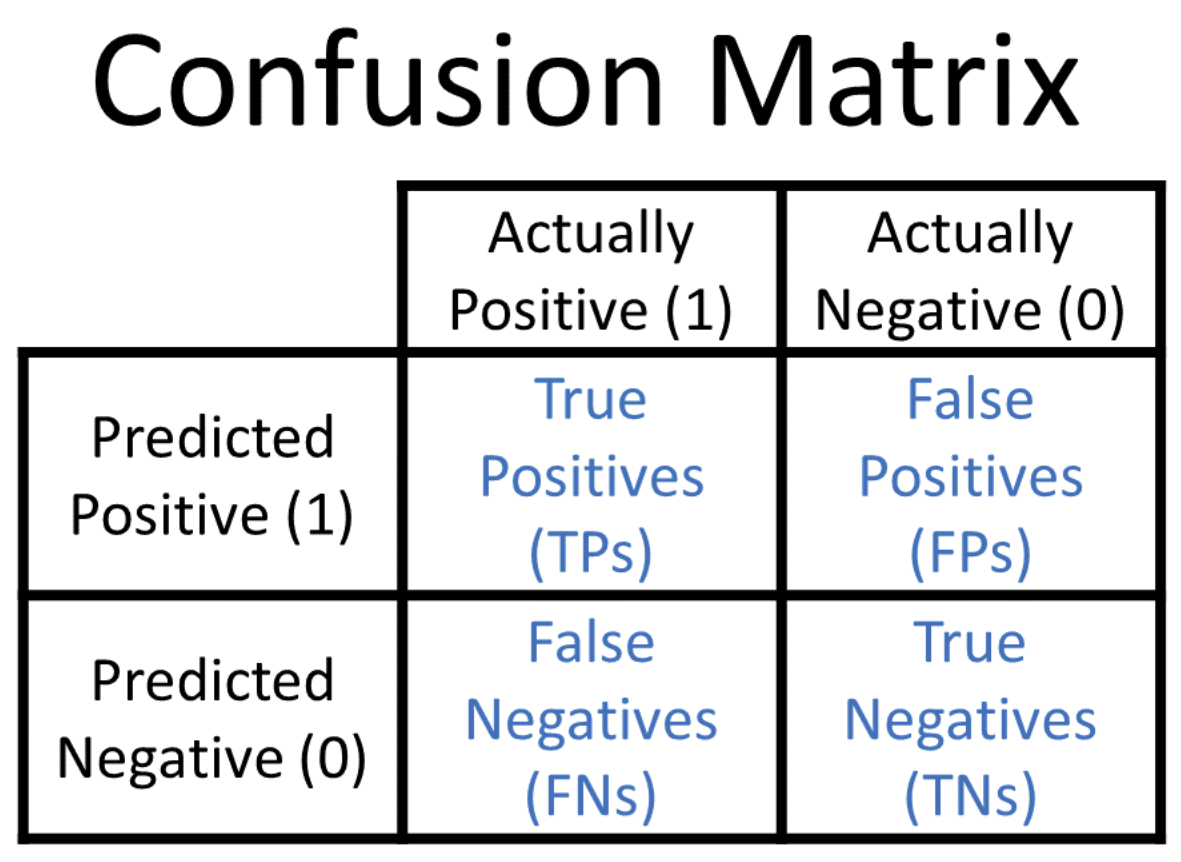

<A HREF=#contents><font size=3>Back to Table of Contents</font></A>